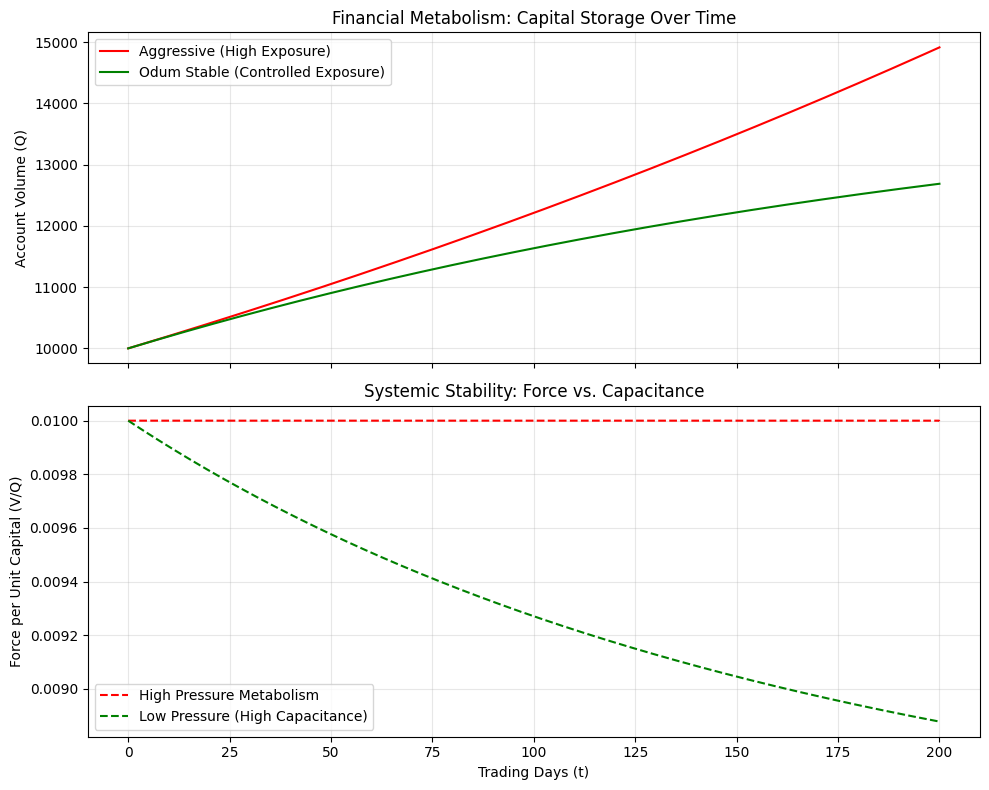

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation Parameters
dt = 0.1  # Time step (days)
T = 200  # Total duration of simulation
steps = int(T / dt)
time = np.linspace(0, T, steps)

# Initial System State
Q_init = 10000  # Initial Capital (Volume)
J_rate = 120  # Base Profit Inflow
k = 0.01  # System Drain (Commissions, Slippage, 'Entropy')


def simulate_metabolism(growth_type="stable"):
    """
    Simulates capital growth based on Odum's Theory of Storage.
    'aggressive': Surface Area (A) grows linearly with Volume (Q).
    'stable': Volume (Q) grows faster than Surface Area (A).
    """
    Q = np.zeros(steps)
    V_per_Q = np.zeros(steps)  # Pressure per unit of capital
    A_history = np.zeros(steps)

    Q[0] = Q_init
    A = 100  # Initial Surface Area (Market Exposure)

    for i in range(1, steps):
        # 1. Define Capacitance (C) as Volume-to-Surface ratio
        # C = Q / A
        C = Q[i - 1] / A

        # 2. Calculate Force/Pressure (V = Q / C)
        # In this geometry, V is equivalent to the Exposure (A)
        V = Q[i - 1] / C

        # 3. Record Pressure per Unit Capital (V/Q = 1/C)
        V_per_Q[i - 1] = V / Q[i - 1]
        A_history[i - 1] = A

        # 4. Odum's Storage Equation: dQ/dt = J - kQ
        # Profit (J) is driven by Force/Exposure (V)
        # Costs (kQ) are the metabolic drain on the storage
        J = J_rate * (V / 100)
        dQ = (J - k * Q[i - 1]) * dt

        Q[i] = Q[i - 1] + dQ

        # 5. Evolution of Surface Area (A)
        if growth_type == "aggressive":
            # Exposure scales 1:1 with capital (Pressure remains high)
            A = 100 * (Q[i] / Q_init)
        else:
            # Stable: Capital grows faster than Exposure (Pressure decreases)
            A = 100 * np.sqrt(Q[i] / Q_init)

    V_per_Q[-1] = V / Q[-1]
    return Q, V_per_Q


# Execute Simulations
q_aggressive, v_aggressive = simulate_metabolism("aggressive")
q_stable, v_stable = simulate_metabolism("stable")

# Plotting the 'Macroscope' Analysis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot 1: Capital Volume (Q)
ax1.plot(time, q_aggressive, label="Aggressive (High Exposure)", color="red")
ax1.plot(time, q_stable, label="Odum Stable (Controlled Exposure)", color="green")
ax1.set_ylabel("Account Volume (Q)")
ax1.set_title("Financial Metabolism: Capital Storage Over Time")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Pressure per Unit Capital (V/Q)
ax2.plot(
    time, v_aggressive, label="High Pressure Metabolism", color="red", linestyle="--"
)
ax2.plot(
    time,
    v_stable,
    label="Low Pressure (High Capacitance)",
    color="green",
    linestyle="--",
)
ax2.set_ylabel("Force per Unit Capital (V/Q)")
ax2.set_xlabel("Trading Days (t)")
ax2.set_title("Systemic Stability: Force vs. Capacitance")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<>:92: SyntaxWarning: invalid escape sequence '\s'
<>:92: SyntaxWarning: invalid escape sequence '\s'
/var/folders/fm/w2754yl54jlgmv1z6fcgtqfh0000gn/T/ipykernel_23240/4262818503.py:92: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_title("System Geometry: Exposure Scaling ($\sqrt{Q}$)")


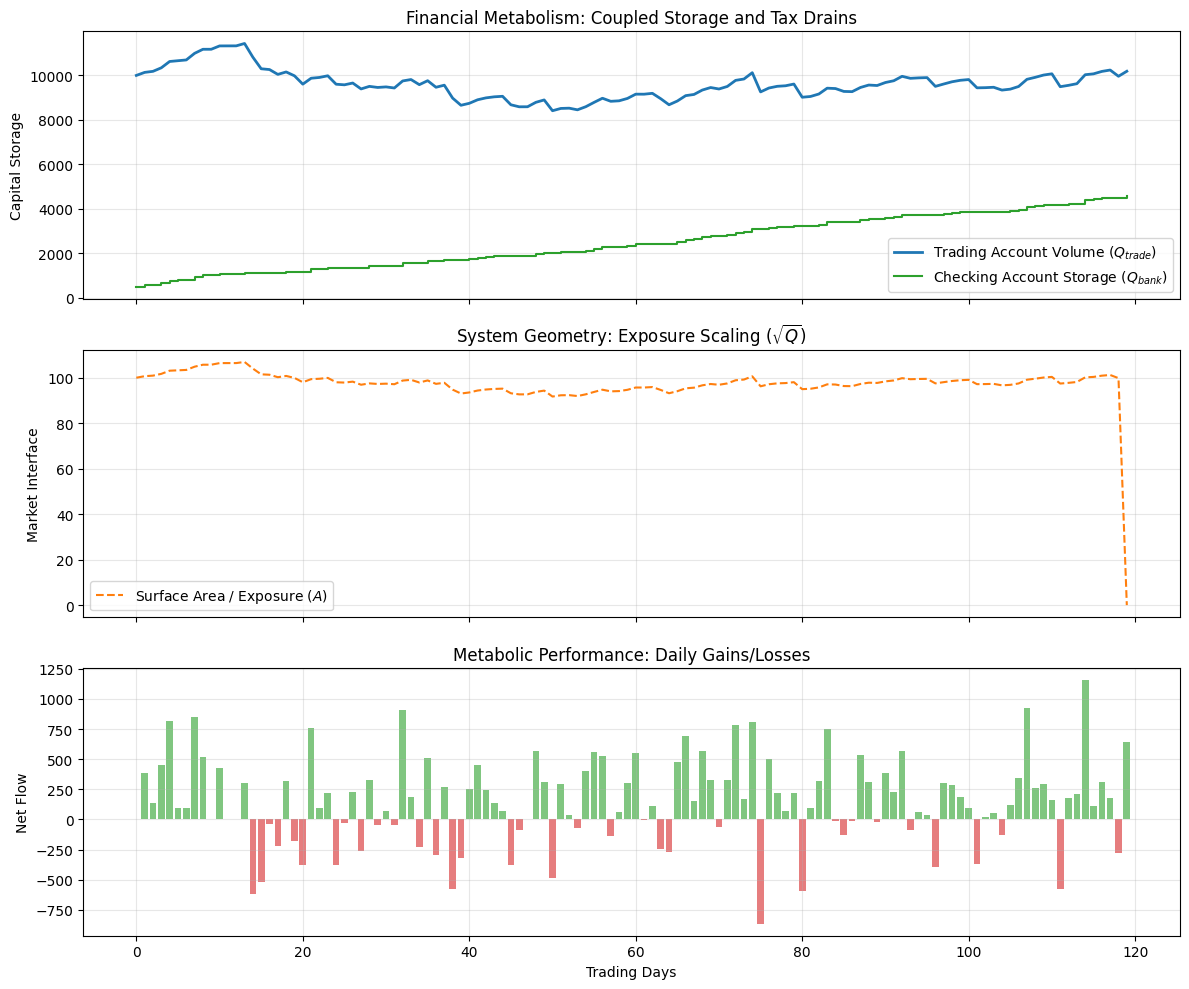

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
np.random.seed(42)
days = 120
initial_q = 10000
tax_rate = 0.50  # 50% Capital Gains Tax (The 'State' Sink)
friction_k = 0.001  # Transaction costs/Slippage (Entropy)
harvest_rate = 0.3  # 30% of net profit moved to 'Safe' storage (Bank)
base_edge = 0.02  # Your 'Energy Edge' or strategy signal

# --- Storage Capacitors ---
q_trade = np.zeros(days)  # Active Capital Volume
q_bank = np.zeros(days)  # Bank/Checking Storage
pnl_history = np.zeros(days)
exposure_a = np.zeros(days)

q_trade[0] = initial_q
q_bank[0] = 500

# --- The Simulation Loop ---
for t in range(1, days):
    # 1. Geometric Scaling: Surface Area (A) grows slower than Volume (Q)
    # This increases 'Capacitance' (C = Q/A)
    # A represents the 'Interface' between your capital and the market
    current_a = 100 * np.sqrt(q_trade[t - 1] / initial_q)
    exposure_a[t - 1] = current_a

    # 2. Force (V) and Flow (J)
    # In Energese: V = Q / C. Since C = Q/A, V = A.
    # Market 'Force' is equivalent to your exposure/position size
    v_force = current_a

    # 3. The Work Gate Interaction
    # Daily return is driven by 'Force' (Exposure) * 'Edge' (Signal)
    volatility = 0.04
    market_return = np.random.normal(base_edge, volatility)

    # Gross Flow (J) = Position Size * Market Return
    # Position size is proportional to our Force (V)
    position_multiplier = 100  # Scaling factor for simulation
    j_flow = (v_force * position_multiplier) * market_return

    # 4. Metabolic Drains (Costs and Entropy)
    costs = q_trade[t - 1] * friction_k
    net_before_tax = j_flow - costs

    # 5. The Shunts (Tax and Bank Harvesting)
    if net_before_tax > 0:
        # Tax Drain (50%)
        tax_drain = net_before_tax * tax_rate
        net_after_tax = net_before_tax - tax_drain

        # Diverted Flow to Bank Capacitor
        to_bank = net_after_tax * harvest_rate
        to_reinvest = net_after_tax - to_bank

        q_trade[t] = q_trade[t - 1] + to_reinvest
        q_bank[t] = q_bank[t - 1] + to_bank
    else:
        # Losses deplete the Active Capacitor Volume
        q_trade[t] = q_trade[t - 1] + net_before_tax
        q_bank[t] = q_bank[t - 1]

    pnl_history[t] = net_before_tax

# --- Plotting the 'Macroscope' Analysis ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: Storage Capacitors (Volumes)
ax1.plot(
    q_trade, label="Trading Account Volume ($Q_{trade}$)", color="#1f77b4", linewidth=2
)
ax1.step(
    range(days),
    q_bank,
    label="Checking Account Storage ($Q_{bank}$)",
    color="#2ca02c",
    where="post",
)
ax1.set_ylabel("Capital Storage")
ax1.set_title("Financial Metabolism: Coupled Storage and Tax Drains")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Geometry (Surface Area / Exposure)
ax2.plot(
    exposure_a, label="Surface Area / Exposure ($A$)", color="#ff7f0e", linestyle="--"
)
ax2.set_ylabel("Market Interface")
ax2.set_title("System Geometry: Exposure Scaling ($\sqrt{Q}$)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Daily Flow (J)
colors = ["#2ca02c" if x > 0 else "#d62728" for x in pnl_history]
ax3.bar(range(days), pnl_history, color=colors, alpha=0.6, label="Daily Flow ($J$)")
ax3.set_ylabel("Net Flow")
ax3.set_xlabel("Trading Days")
ax3.set_title("Metabolic Performance: Daily Gains/Losses")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

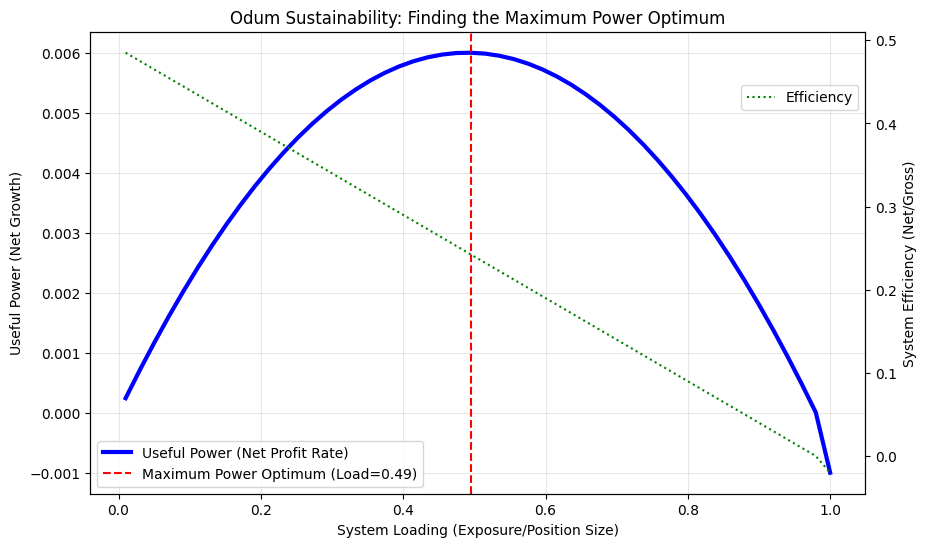

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters for Power Analysis ---
load_levels = np.linspace(0.01, 1.0, 50)  # Range of exposure/risk levels
tax_rate = 0.50
friction_base = 0.001
edge = 0.05  # Strategy signal strength

power_output = []
efficiency = []

for load in load_levels:
    # Gross Flow (J) is proportional to the Load (Exposure)
    gross_j = load * edge

    # Resistance/Entropy (Costs) often scales non-linearly with size
    # Large trades incur more slippage (Odum's 'quadratic' friction)
    costs = (load * friction_base) + (0.05 * (load**2))

    net_before_tax = gross_j - costs

    # Net Power (Useful work after the 'State Sink')
    if net_before_tax > 0:
        net_power = net_before_tax * (1 - tax_rate)
    else:
        net_power = net_before_tax  # Losses hit the system fully

    power_output.append(net_power)
    # Efficiency = Useful Power / Total Gross Input
    eff = net_power / gross_j if gross_j > 0 else 0
    efficiency.append(eff)

# --- Find the Optimum ---
optimum_idx = np.argmax(power_output)
max_power_load = load_levels[optimum_idx]

# --- Plotting the Maximum Power Optimum ---
plt.figure(figsize=(10, 6))
plt.plot(
    load_levels,
    power_output,
    label="Useful Power (Net Profit Rate)",
    color="blue",
    linewidth=3,
)
plt.axvline(
    x=max_power_load,
    color="red",
    linestyle="--",
    label=f"Maximum Power Optimum (Load={max_power_load:.2f})",
)

plt.title("Odum Sustainability: Finding the Maximum Power Optimum")
plt.xlabel("System Loading (Exposure/Position Size)")
plt.ylabel("Useful Power (Net Growth)")
plt.legend()
plt.grid(True, alpha=0.3)

# Add Efficiency curve on a second Y-axis
ax2 = plt.gca().twinx()
ax2.plot(load_levels, efficiency, label="Efficiency", color="green", linestyle=":")
ax2.set_ylabel("System Efficiency (Net/Gross)")
ax2.legend(loc="upper right", bbox_to_anchor=(1, 0.9))

plt.show()

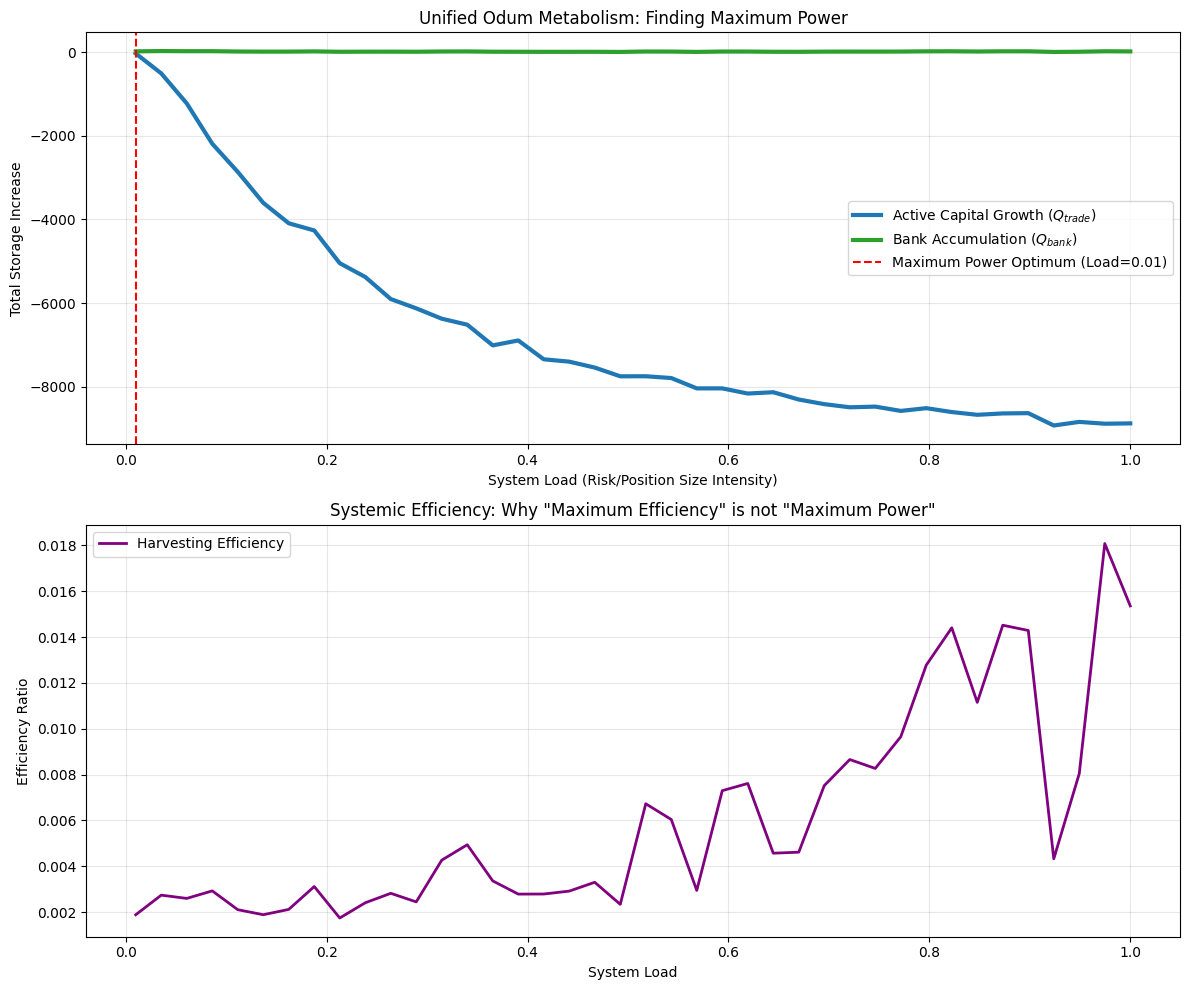

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
tax_rate = 0.50  # 50% Capital Gains Tax (High-Resistance Sink)
friction_coeff = 0.005  # Non-linear slippage/entropy factor
days = 100  # Simulation duration for each 'load' level
initial_q = 10000
edge = 0.04  # Market signal quality (The 'Energy Edge')

# --- Simulation Variables ---
loading_levels = np.linspace(0.01, 1.0, 40)  # Position size scaling
net_growth_results = []
efficiency_results = []
bank_accumulation = []

# --- The Unified Simulation Loop ---
for load in loading_levels:
    q_trade = initial_q
    q_bank = 0
    total_net_profit = 0

    for t in range(days):
        # 1. Geometric Scaling: A = sqrt(Q) * load
        # Surface area (exposure) scales with volume and current 'load' intensity
        surface_area = load * np.sqrt(q_trade / initial_q)

        # 2. Force and Flow (J = Force * Edge)
        # Position size is the force generated by our interface
        position_size = q_trade * surface_area * 0.5
        daily_return = np.random.normal(edge, 0.05)
        gross_j = position_size * daily_return

        # 3. Entropy (Friction scales quadratically with position size)
        costs = friction_coeff * (position_size**1.5)
        net_before_tax = gross_j - costs

        # 4. The Shunts (Tax and Bank)
        if net_before_tax > 0:
            tax_drain = net_before_tax * tax_rate
            after_tax = net_before_tax - tax_drain

            # Harvest 30% to Bank storage
            to_bank = after_tax * 0.3
            to_reinvest = after_tax - to_bank

            q_trade += to_reinvest
            q_bank += to_bank
        else:
            # Losses deplete active storage
            q_trade += net_before_tax

    net_growth_results.append(q_trade - initial_q)
    bank_accumulation.append(q_bank)
    efficiency_results.append(
        q_bank / (q_trade + q_bank) if (q_trade + q_bank) > 0 else 0
    )

# --- Finding the Optimum ---
optimum_idx = np.argmax(net_growth_results)
max_power_load = loading_levels[optimum_idx]

# --- Unified Visualization ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: The Maximum Power Curve
ax1.plot(
    loading_levels,
    net_growth_results,
    label="Active Capital Growth ($Q_{trade}$)",
    color="#1f77b4",
    lw=3,
)
ax1.plot(
    loading_levels,
    bank_accumulation,
    label="Bank Accumulation ($Q_{bank}$)",
    color="#2ca02c",
    lw=3,
)
ax1.axvline(
    x=max_power_load,
    color="red",
    ls="--",
    label=f"Maximum Power Optimum (Load={max_power_load:.2f})",
)
ax1.set_title("Unified Odum Metabolism: Finding Maximum Power")
ax1.set_xlabel("System Load (Risk/Position Size Intensity)")
ax1.set_ylabel("Total Storage Increase")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Efficiency vs. Power (The Sustainability Trade-off)
ax2.plot(
    loading_levels,
    efficiency_results,
    label="Harvesting Efficiency",
    color="purple",
    lw=2,
)
ax2.set_title('Systemic Efficiency: Why "Maximum Efficiency" is not "Maximum Power"')
ax2.set_xlabel("System Load")
ax2.set_ylabel("Efficiency Ratio")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

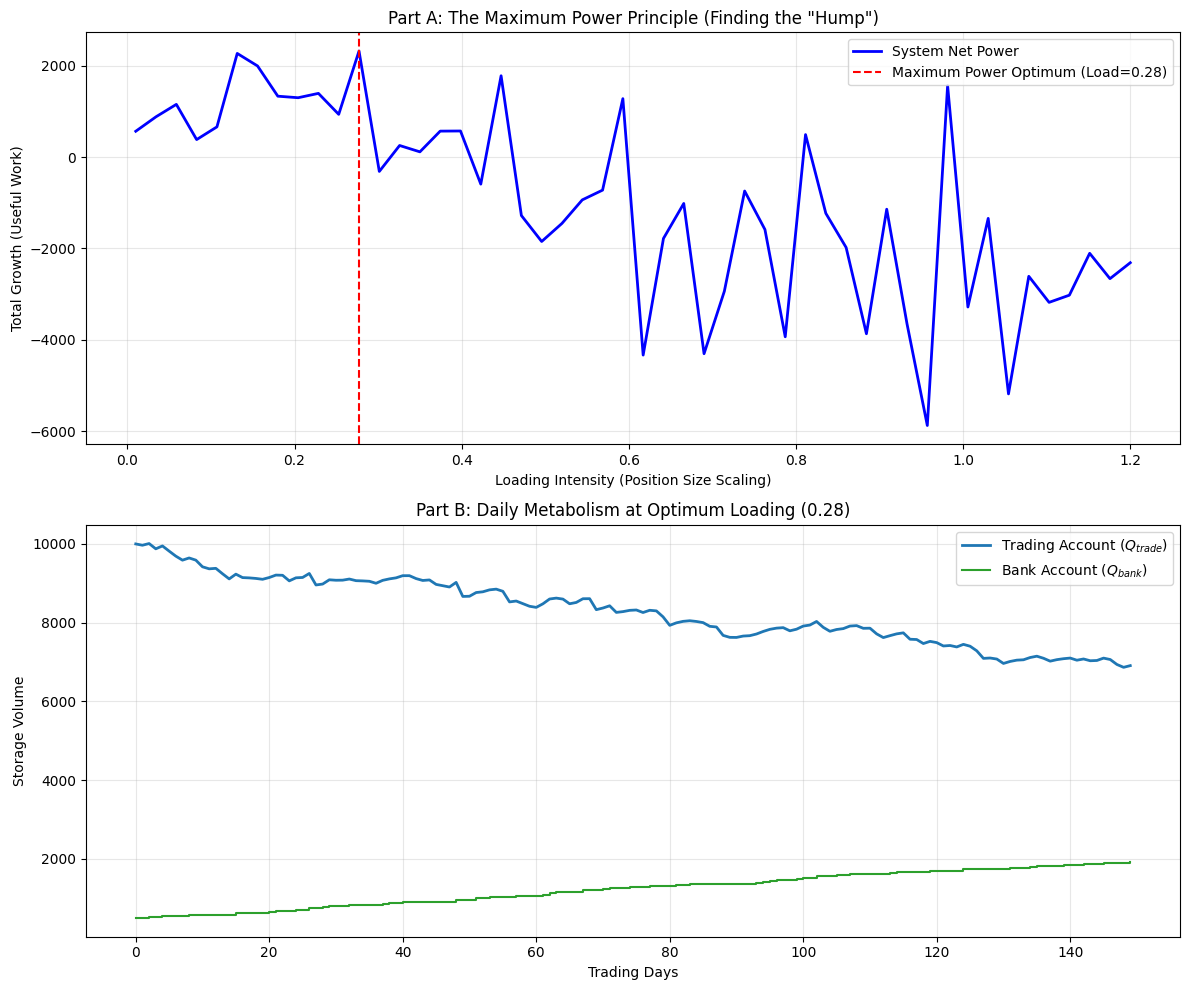

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION (The System Environment) ---
np.random.seed(42)
days = 150
initial_q = 10000
tax_rate = 0.50  # 50% Capital Gains Tax (Parasitic Drain)
friction_coeff = 0.005  # Slippage/Resistance (Entropy)
edge = 0.04  # Signal quality (Energy Input)
withdraw_rate = 0.3  # Flow from Trade Capacitor to Bank Capacitor


def run_simulation(load):
    q_trade = np.zeros(days)
    q_bank = np.zeros(days)
    q_trade[0] = initial_q
    q_bank[0] = 500

    for t in range(1, days):
        # Geometric Scaling: Surface Area (A) = Load * sqrt(Q)
        # Higher load = more market interface/exposure
        surface_area = load * np.sqrt(q_trade[t - 1] / initial_q)

        # Power Flow (J): Driven by Surface Area and Edge
        daily_return = np.random.normal(edge, 0.06)
        gross_flow = (q_trade[t - 1] * surface_area) * daily_return

        # Resistance: Non-linear friction (Heat Sink)
        resistance = friction_coeff * (surface_area * q_trade[t - 1]) ** 1.2
        net_before_tax = gross_flow - resistance

        if net_before_tax > 0:
            tax = net_before_tax * tax_rate
            after_tax = net_before_tax - tax
            harvest = after_tax * withdraw_rate

            q_trade[t] = q_trade[t - 1] + (after_tax - harvest)
            q_bank[t] = q_bank[t - 1] + harvest
        else:
            # Losses are 100% volume depletion
            q_trade[t] = q_trade[t - 1] + net_before_tax
            q_bank[t] = q_bank[t - 1]

    return q_trade, q_bank


# --- 2. THE SEARCH FOR MAXIMUM POWER (The "Hump" Plot) ---
loads = np.linspace(0.01, 1.2, 50)
final_total_power = []

for l in loads:
    qt, qb = run_simulation(l)
    # Total Power = Net gain in system storage
    final_total_power.append((qt[-1] + qb[-1]) - initial_q)

optimum_load = loads[np.argmax(final_total_power)]

# --- 3. THE TIME-SERIES AT OPTIMUM (The Performance Plot) ---
opt_qt, opt_qb = run_simulation(optimum_load)

# --- 4. VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top Plot: Finding the Optimum (Maximum Power Principle)
ax1.plot(loads, final_total_power, color="blue", lw=2, label="System Net Power")
ax1.axvline(
    optimum_load,
    color="red",
    ls="--",
    label=f"Maximum Power Optimum (Load={optimum_load:.2f})",
)
ax1.set_title('Part A: The Maximum Power Principle (Finding the "Hump")')
ax1.set_xlabel("Loading Intensity (Position Size Scaling)")
ax1.set_ylabel("Total Growth (Useful Work)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom Plot: The Daily Metabolism at Optimum Load
ax2.plot(opt_qt, label="Trading Account ($Q_{trade}$)", color="#1f77b4", lw=2)
ax2.step(
    range(days),
    opt_qb,
    label="Bank Account ($Q_{bank}$)",
    color="#2ca02c",
    where="post",
)
ax2.set_title(f"Part B: Daily Metabolism at Optimum Loading ({optimum_load:.2f})")
ax2.set_xlabel("Trading Days")
ax2.set_ylabel("Storage Volume")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()